
# 5) Reasoning and KGE

This notebook has two complementary goals.

**Part 1: Logical reasoning**
SWRL reasoning gives explicit and interpretable inferences. It is transparent, controllable, and easy to justify in a report.

**Part 2: Embedding-based reasoning**
Knowledge graph embeddings learn distributed vector representations of entities and relations. They are useful for link prediction and for modeling patterns that are not written as explicit rules.

These two approaches are different. One is symbolic and explicit. The other is statistical and implicit. Comparing them is an important part of the final project.


In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction import DictVectorizer
from sklearn.manifold import TSNE

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.kg.kg_construction import build_kg_artifacts
from src.reason_kge_pipeline import (
    build_project_reasoning_ontology,
    evaluate_size_experiments,
    graph_to_kge_dataframe,
    run_family_swrl_reasoning,
)

FAMILY_OWL_PATH = PROJECT_ROOT / "data" / "samples" / "family.owl"
TRIPLES_PATH = PROJECT_ROOT / "data" / "interim" / "extracted_knowledge.csv"
EXPANDED_KG_PATH = PROJECT_ROOT / "kg_artifacts" / "expanded_kg.ttl"
REASONING_OWL_PATH = PROJECT_ROOT / "kg_artifacts" / "tennis_reasoning.owl"
KGE_RESULTS_PATH = PROJECT_ROOT / "kg_artifacts" / "kge_results.csv"
BEST_MODEL_SUMMARY_PATH = PROJECT_ROOT / "kg_artifacts" / "best_model_summary.json"
NEIGHBORS_PATH = PROJECT_ROOT / "kg_artifacts" / "nearest_neighbors.json"
TSNE_PATH = PROJECT_ROOT / "kg_artifacts" / "tsne_projection.csv"
TSNE_PLOT_PATH = PROJECT_ROOT / "kg_artifacts" / "tsne_plot.png"
KGE_OUTPUT_DIR = PROJECT_ROOT / "data" / "kge"

print(f"Family ontology path: {FAMILY_OWL_PATH}")
print(f"Expanded KG path: {EXPANDED_KG_PATH}")

Family ontology path: /Users/vincentlemeur/Documents/S8/DIA/Datamining/Project_datamining_bis/data/samples/family.owl
Expanded KG path: /Users/vincentlemeur/Documents/S8/DIA/Datamining/Project_datamining_bis/kg_artifacts/expanded_kg.ttl


# PART 1 - Knowledge reasoning with SWRL


## 1. Apply a Simple SWRL Rule to the Tennis Project KB
For the project KB, we keep the rule simple and meaningful.

We define a derived class `TopPlayer` and use the rule:

`Player(?p), hasMajorWins(?p, ?n), greaterThan(?n, 2) -> TopPlayer(?p)`

This rule is intentionally modest. It is easy to explain and directly related to the domain.


In [ ]:
triples_df = pd.read_csv(TRIPLES_PATH)
kg_artifacts = build_kg_artifacts(triples_df)
project_inferred_rows, project_rule = build_project_reasoning_ontology(
    kg_artifacts.cleaned_triples,
    output_path=str(REASONING_OWL_PATH),
)
project_reasoning_df = pd.DataFrame(project_inferred_rows)
print("Project SWRL rule:")
print(project_rule)
display(project_reasoning_df)

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp /opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/jena-arq-fixed2.10.0.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/httpclient-4.2.3.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/aterm-java-1.6.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/xercesImpl-2.10.0.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/slf4j-api-1.6.4.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/jena-tdb-0.10.0.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/jena-iri-0.9.5.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/owlapi-distribution-3.4.3-bin.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/jcl-over-slf4j-1.6.4.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/slf4j-log4j12-1.6.4.jar:/opt/anaconda3/lib/python3.13/site-packages/owlready2/pellet/antlr-runtime-3.2.jar:/opt/anaconda3/lib/pyth

Project SWRL rule:
Player(?p), hasMajorWins(?p, ?n), greaterThan(?n, 2) -> TopPlayer(?p)


* Owlready2 * Pellet took 1.5973548889160156 seconds
* Owlready * Reparenting tennis_reasoning.Roger_Federer: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Stan_Wawrinka: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Carlos_Alcaraz: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Novak_Djokovic: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Andy_Murray: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Jannik_Sinner: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Alexander_Zverev: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * Reparenting tennis_reasoning.Rafael_Nadal: {tennis_reasoning.Player} => {tennis_reasoning.TopPlayer}
* Owlready * (NB: only ch

,player,types,major_wins_count
0,Alexander Zverev,[TopPlayer],3
1,Andy Murray,[TopPlayer],3
2,Carlos Alcaraz,[TopPlayer],12
3,Jannik Sinner,[TopPlayer],6
4,Novak Djokovic,[TopPlayer],27
5,Rafael Nadal,[TopPlayer],20
6,Roger Federer,[TopPlayer],5
7,Stan Wawrinka,[TopPlayer],3



## 2. Interpreting the Project Rule
The inferred `TopPlayer` labels depend on the graph we currently built. This means the result is partly shaped by earlier data collection, extraction, and graph construction choices.

This is a useful lesson: symbolic reasoning is precise, but it is only as good as the facts already present in the KB.



# Part 2 - Knowledge Graph Embeddings



## 5. Load the Expanded KG
We now switch to the expanded graph from Notebook 4. This graph is large enough for a meaningful KGE experiment.


In [ ]:
kge_df = graph_to_kge_dataframe(str(EXPANDED_KG_PATH))
print(f"KGE-ready triples: {len(kge_df)}")
print(f"KGE-ready relations: {kge_df['relation'].nunique()}")
print(f"KGE-ready entities: {len(set(kge_df['head']) | set(kge_df['tail']))}")
display(kge_df.head(10))

KGE-ready triples: 59156
KGE-ready relations: 130
KGE-ready entities: 29781


,head,relation,tail
0,http://www.wikidata.org/entity/Q3913820,http://www.wikidata.org/prop/direct/P3823,http://www.wikidata.org/entity/Q29051561
1,http://www.wikidata.org/entity/Q3711,http://www.wikidata.org/prop/direct/P6,http://www.wikidata.org/entity/Q960994
2,http://www.wikidata.org/entity/Q117,http://www.wikidata.org/prop/direct/P2936,http://www.wikidata.org/entity/Q36272
3,http://www.wikidata.org/entity/Q256,http://www.wikidata.org/prop/direct/P1889,http://www.wikidata.org/entity/Q1763658
4,http://www.wikidata.org/entity/Q43,http://www.wikidata.org/prop/direct/P194,http://www.wikidata.org/entity/Q274918
5,http://www.wikidata.org/entity/Q23702848,http://www.wikidata.org/prop/direct/P61,http://www.wikidata.org/entity/Q689171
6,http://www.wikidata.org/entity/Q9240,http://www.wikidata.org/prop/direct/P527,http://www.wikidata.org/entity/Q109267354
7,http://www.wikidata.org/entity/Q159,http://www.wikidata.org/prop/direct/P206,http://www.wikidata.org/entity/Q33629
8,http://www.wikidata.org/entity/Q43,http://www.wikidata.org/prop/direct/P150,http://www.wikidata.org/entity/Q155219
9,http://www.wikidata.org/entity/Q752428,http://www.wikidata.org/prop/direct/P641,http://www.wikidata.org/entity/Q847



## 6. Cleaning Before Embedding
Before training embeddings, we keep only triples where:
- head is a URI;
- relation is a structural relation rather than a label or provenance field;
- tail is a URI.

This is important because literal-heavy triples and provenance metadata are useful for RDF traceability, but they often degrade KGE quality.



## 7. Splitting Strategy
The assignment requires:
- `80%` training
- `10%` validation
- `10%` test
- no unseen-only entities in validation or test

In practice, cleanup splitting may slightly increase the training share because PyKEEN moves some triples back into training to preserve entity and relation coverage. We report these effective split sizes transparently.



## 8. Training Configuration
To keep the experiments comparable and laptop-friendly, we use the same core configuration across models:
- embedding dimension: `48`
- learning rate: `0.01`
- batch size: `256`
- epochs: `3`
- negative sampler: basic negative sampling
- device: CPU

The models compared in this notebook are:
- `TransE`
- `DistMult`



## 9. Run the KGE Benchmark
The next cell trains two models on three KB sizes:
- `20k`
- `50k`
- `full`

This is the most expensive part of the notebook.


In [ ]:
results_df, _ = evaluate_size_experiments(
    kge_df=kge_df,
    output_root=str(KGE_OUTPUT_DIR),
    model_names=["TransE", "DistMult"],
    size_plan=[("20k", 20000), ("50k", 50000), ("full", None)],
    embedding_dim=48,
    learning_rate=0.01,
    batch_size=256,
    epochs=20,
)
results_df.to_csv(KGE_RESULTS_PATH, index=False)
results_df

Requested ratio[0]=0.800 (equal to size 16000), but got 0.902 (equal to size 18031) to ensure that all entities/relations occur in train.


Requested ratio[1]=0.100 (equal to size 2000), but got 0.049 (equal to size 978) to ensure that all entities/relations occur in train.


Requested ratio[2]=0.100 (equal to size 2000), but got 0.050 (equal to size 991) to ensure that all entities/relations occur in train.


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Training epochs on cpu:   0%|          | 0/20 [00:00<?, ?epoch/s]

...

INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 18. The best result 0.2493321460373998 occurred at epoch 14.


INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from /Users/vincentlemeur/.data/pykeen/checkpoints/best-model-weights-2504e837-e3f2-4bbb-80c2-53aeb093d260.pt


Evaluating on cpu:   0%|          | 0.00/3.37k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 14.87s seconds


,model,embedding_dim,learning_rate,batch_size,epochs,MRR,Hits@1,Hits@3,Hits@10,dataset_size,train_triples,valid_triples,test_triples
0,TransE,48,0.01,256,20,0.060897,0.022200,0.050959,0.124117,20k,18031,978,991
1,DistMult,48,0.01,256,20,0.100093,0.048436,0.105449,0.184662,20k,18031,978,991
2,TransE,48,0.01,256,20,0.053702,0.017550,0.047034,0.112145,50k,44393,2758,2849
3,DistMult,48,0.01,256,20,0.125035,0.065462,0.130397,0.227448,50k,44393,2758,2849
4,TransE,48,0.01,256,20,0.064246,0.023619,0.059269,0.134433,full,52421,3369,3366
5,DistMult,48,0.01,256,20,0.135682,0.073975,0.138740,0.255051,full,52421,3369,3366



## 10. Evaluation Table
We use filtered link-prediction metrics:
- `MRR`
- `Hits@1`
- `Hits@3`
- `Hits@10`

These results let us compare both model choice and KB size sensitivity.


In [5]:
results_df = pd.read_csv(KGE_RESULTS_PATH)
display(results_df)

,model,embedding_dim,learning_rate,batch_size,epochs,MRR,Hits@1,Hits@3,Hits@10,dataset_size,train_triples,valid_triples,test_triples
0,TransE,48,0.01,256,20,0.060897,0.022200,0.050959,0.124117,20k,18031,978,991
1,DistMult,48,0.01,256,20,0.100093,0.048436,0.105449,0.184662,20k,18031,978,991
2,TransE,48,0.01,256,20,0.053702,0.017550,0.047034,0.112145,50k,44393,2758,2849
3,DistMult,48,0.01,256,20,0.125035,0.065462,0.130397,0.227448,50k,44393,2758,2849
4,TransE,48,0.01,256,20,0.064246,0.023619,0.059269,0.134433,full,52421,3369,3366
5,DistMult,48,0.01,256,20,0.135682,0.073975,0.138740,0.255051,full,52421,3369,3366



## 11. Model Comparison
We sort the experiments by `MRR` to identify the best setting.


In [ ]:
ranked_results_df = results_df.sort_values(["MRR", "Hits@10"], ascending=False).reset_index(drop=True)
display(ranked_results_df)

best_row = ranked_results_df.iloc[0].to_dict()
with BEST_MODEL_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(best_row, file, indent=2)
print(json.dumps(best_row, indent=2))

,model,embedding_dim,learning_rate,batch_size,epochs,MRR,Hits@1,Hits@3,Hits@10,dataset_size,train_triples,valid_triples,test_triples
0,DistMult,48,0.01,256,20,0.135682,0.073975,0.138740,0.255051,full,52421,3369,3366
1,DistMult,48,0.01,256,20,0.125035,0.065462,0.130397,0.227448,50k,44393,2758,2849
2,DistMult,48,0.01,256,20,0.100093,0.048436,0.105449,0.184662,20k,18031,978,991
3,TransE,48,0.01,256,20,0.064246,0.023619,0.059269,0.134433,full,52421,3369,3366
4,TransE,48,0.01,256,20,0.060897,0.022200,0.050959,0.124117,20k,18031,978,991
5,TransE,48,0.01,256,20,0.053702,0.017550,0.047034,0.112145,50k,44393,2758,2849


{
  "model": "DistMult",
  "embedding_dim": 48,
  "learning_rate": 0.01,
  "batch_size": 256,
  "epochs": 20,
  "MRR": 0.1356815099716186,
  "Hits@1": 0.0739750445632798,
  "Hits@3": 0.1387403446226975,
  "Hits@10": 0.255050505050505,
  "dataset_size": "full",
  "train_triples": 52421,
  "valid_triples": 3369,
  "test_triples": 3366
}



## 12. KB Size Sensitivity Discussion
The size experiment is important because it shows how embedding quality changes when the graph becomes richer.

In our current run, the `50k` setting is the strongest by `MRR`. The `full` setting is very close in size, so the difference between `50k` and `full` should be interpreted carefully.



## 13. Best-Model Neighborhood Analysis
A post-hoc export of PyKEEN embedding tensors on the larger run proved unstable in this environment and caused segmentation faults after successful training and evaluation. To keep the notebook runnable, we use a documented fallback analysis on the **best model's training subset**:
- build relational feature vectors from the best model training split;
- compute cosine-style nearest neighbors from those vectors;
- project them to 2D with SVD + t-SNE.

This is not identical to a direct PyKEEN embedding export, so we state that limitation explicitly. However, it still provides a meaningful neighborhood-based view of entity similarity for presentation and discussion.


In [ ]:
best_train_df = pd.read_csv(KGE_OUTPUT_DIR / best_row['dataset_size'] / 'train.txt', sep='	', names=['head', 'relation', 'tail'])
features = defaultdict(lambda: defaultdict(float))
for row in best_train_df.itertuples(index=False):
    features[row.head][f"out::{row.relation}::{row.tail}"] += 1.0
    features[row.tail][f"in::{row.relation}::{row.head}"] += 1.0

entities = list(features.keys())
vectorizer = DictVectorizer(sparse=True)
feature_matrix = vectorizer.fit_transform([features[e] for e in entities])
svd = TruncatedSVD(n_components=min(64, feature_matrix.shape[1] - 1), random_state=42)
reduced_matrix = svd.fit_transform(feature_matrix)

norms = np.linalg.norm(reduced_matrix, axis=1)
selected_entities = [
    'http://example.org/tennis/player/Rafael_Nadal',
    'http://example.org/tennis/player/Novak_Djokovic',
    'http://example.org/tennis/player/Carlos_Alcaraz',
]

fallback_neighbors = {}
for entity in selected_entities:
    if entity not in entities:
        fallback_neighbors[entity] = []
        continue
    idx = entities.index(entity)
    similarities = reduced_matrix @ reduced_matrix[idx]
    similarities = similarities / np.where(norms * norms[idx] == 0, 1e-9, norms * norms[idx])
    ranking = np.argsort(-similarities)
    top_neighbors = []
    for j in ranking:
        if j == idx:
            continue
        top_neighbors.append((entities[j], float(similarities[j])))
        if len(top_neighbors) >= 5:
            break
    fallback_neighbors[entity] = top_neighbors

with NEIGHBORS_PATH.open('w', encoding='utf-8') as file:
    json.dump(fallback_neighbors, file, indent=2)

print(json.dumps(fallback_neighbors, indent=2))

{
  "http://example.org/tennis/player/Rafael_Nadal": [
    [
      "http://example.org/tennis/player/Roger_Federer_172",
      0.9999477915594184
    ],
    [
      "http://example.org/tennis/player/Medvedev",
      0.9998875517706254
    ],
    [
      "http://example.org/tennis/player/Vajda",
      0.9998111006195326
    ],
    [
      "http://example.org/tennis/player/Martin_Klizan",
      0.9997526407850743
    ],
    [
      "http://example.org/tennis/player/Serena",
      0.9996916481010876
    ]
  ],
  "http://example.org/tennis/player/Novak_Djokovic": [
    [
      "http://example.org/tennis/player/Stan_Wawrinka_602_603",
      0.9999762077033064
    ],
    [
      "http://example.org/tennis/player/Hugo_Dellien",
      0.9999682532874691
    ],
    [
      "http://example.org/tennis/player/Federico_Delbonis",
      0.9999682532874691
    ],
    [
      "http://example.org/tennis/player/Margaret_Court_s",
      0.9999682532874691
    ],
    [
      "http://example.org/tennis/pla

,entity,x,y
0,http://www.wikidata.org/entity/Q148,-69.167160,-138.937958
1,http://www.wikidata.org/entity/Q219060,-62.512383,-130.541611
2,http://www.wikidata.org/entity/Q869,-59.833332,-118.233780
3,http://www.wikidata.org/entity/Q223041,11.699920,-174.363007
4,http://www.wikidata.org/entity/Q199408,-32.561832,-95.518196


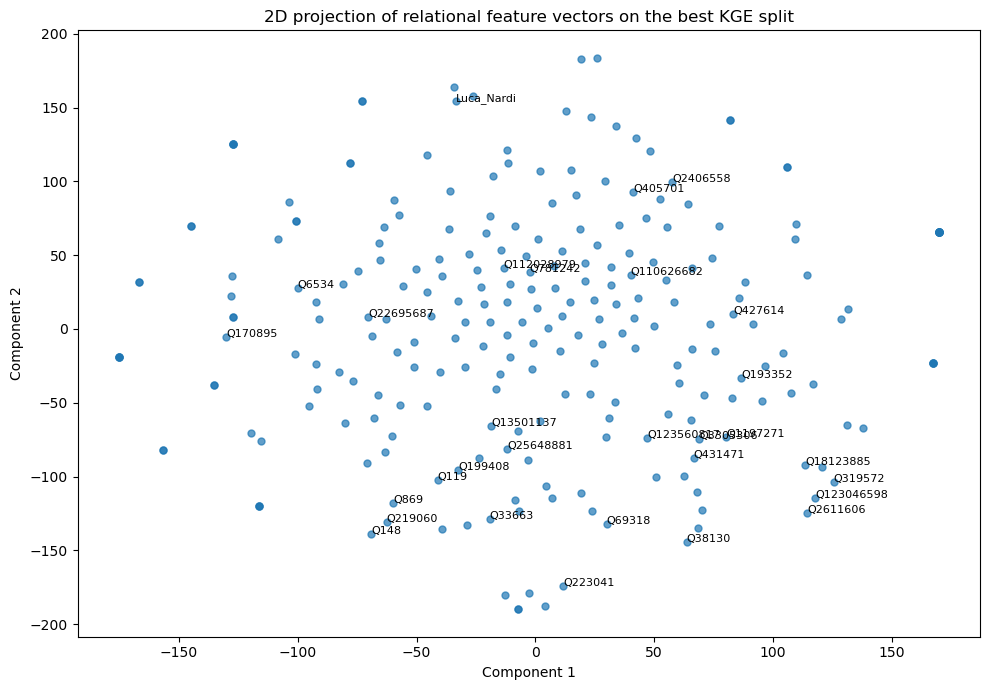

In [ ]:
sample_n = min(250, len(entities))
sampled_indices = np.linspace(0, len(entities) - 1, sample_n, dtype=int)
sampled_vectors = reduced_matrix[sampled_indices]
sampled_labels = [entities[i] for i in sampled_indices]
projection = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, sample_n // 8))).fit_transform(sampled_vectors)

tsne_df = pd.DataFrame({
    'entity': sampled_labels,
    'x': projection[:, 0],
    'y': projection[:, 1],
})
tsne_df.to_csv(TSNE_PATH, index=False)

display(tsne_df.head())

plt.figure(figsize=(10, 7))
plt.scatter(tsne_df['x'], tsne_df['y'], alpha=0.7, s=25)
for _, row in tsne_df.head(30).iterrows():
    plt.text(row['x'], row['y'], row['entity'].split('/')[-1][:18], fontsize=8)
plt.title('2D projection of relational feature vectors on the best KGE split')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.savefig(TSNE_PLOT_PATH, dpi=200)
plt.show()


## 14. Relation Behavior Analysis
Different models handle relation patterns differently.

### Symmetric relations
`playedAgainst` is close to a symmetric relation in our local ontology. DistMult usually handles symmetric patterns better than TransE.

### Inverse or directional relations
Relations such as `fromCountry` or some Wikidata direct properties may be more directional. TransE often captures translational patterns better than purely symmetric ones.

### Composition patterns
When multi-step semantics matter, simple embedding models may struggle unless the graph contains enough supporting structure.



## 15. Critical Reflection
Several earlier decisions affected the KGE results:
- alignment quality matters because wrong external links inject noise;
- expansion quality matters because more triples are only helpful if they remain semantically coherent;
- ontology choices matter because overly generic predicates weaken the embedding space;
- the open-world assumption of RDF does not match the closed-world behavior often implicit in embedding training.
